<a href="https://colab.research.google.com/github/riza93n-hub/data-science-2026/blob/main/Pertemuan7_RIZA_250401020014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aktivitas Hands On Pertemuan 7
**Nama Mahasiswa:** RIZA  
**NIM:** 250401020014  
**Kelas:** IF401

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


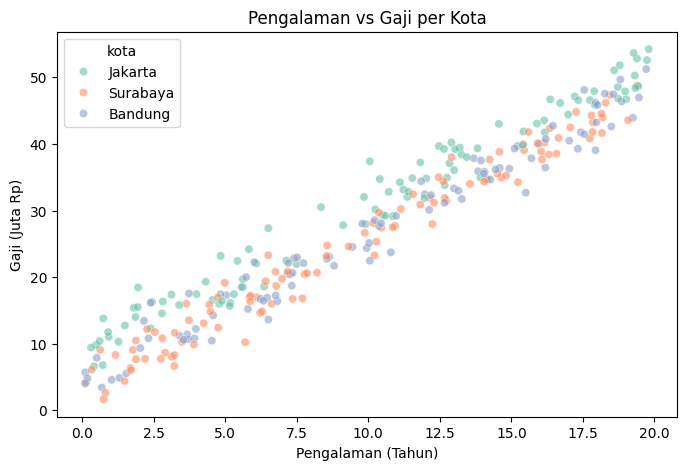

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate dataset sintetis
np.random.seed(42)
n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n) # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
        + np.where(kota=='Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

df = pd.DataFrame({'pengalaman':pengalaman, 'edu':edu, 'kota':kota, 'gaji':gaji})

# 2. EDA singkat
print('Shape:', df.shape)
print(df.describe().round(2))

# Scatter: pengalaman vs gaji
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.xlabel('Pengalaman (Tahun)')
plt.ylabel('Gaji (Juta Rp)')
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

# StandardScaler — fit pada training set saja
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_s, y_train)

# Tampilkan koefisien
print(f'β0 (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
    'Fitur' : X.columns,
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

β0 (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


### Interpretasi Koefisien Model:
Berdasarkan hasil koefisien yang diperoleh dari model regresi, kita dapat menarik beberapa poin penting:
* **Pengalaman Kerja:** Fitur ini memiliki nilai koefisien positif terbesar. Hal ini menunjukkan bahwa pengalaman kerja merupakan faktor paling dominan yang memengaruhi peningkatan gaji dalam dataset ini.
* **Pendidikan (`edu`):** Nilai koefisien positif pada fitur ini menunjukkan bahwa tingkat pendidikan yang lebih tinggi berbanding lurus dengan estimasi kenaikan gaji yang diterima.
* **Faktor Kota Asal:** Karena kategori **Bandung** digunakan sebagai dasar pembanding (*baseline*), maka:
  * Pekerja yang berada di **Jakarta** memiliki kecenderungan untuk mendapatkan gaji lebih tinggi dibandingkan pekerja di Bandung, meskipun memiliki pengalaman dan tingkat pendidikan yang sama.
  * Sebaliknya, pekerja di **Surabaya** memiliki nilai koefisien negatif, yang berarti estimasi gajinya cenderung sedikit lebih rendah jika dibandingkan dengan baseline di Bandung.

In [4]:
# Import root_mean_squared_error secara eksplisit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

y_pred = model.predict(X_test_s)
mae = mean_absolute_error(y_test, y_pred)

# Menggunakan fungsi baru bawaan scikit-learn versi terbaru
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R2 = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

=== Metrik Evaluasi ===
MAE = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R2 = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


### Analisis Metrik Evaluasi:
1. **Rata-rata Kesalahan Prediksi:** Berdasarkan nilai MAE, rata-rata kesalahan prediksi model secara absolut adalah sekitar 1,56 juta rupiah. Sementara itu, nilai RMSE menunjukkan deviasi kesalahan sebesar 1,91 juta rupiah. Secara umum, selisih prediksi model terhadap gaji aktual berkisar pada angka tersebut.
2. **Kebaikan Model ($R^2$):** Nilai $R^2$ yang mencapai 0,9574 menunjukkan bahwa sekitar 95,7% variasi atau naik-turunnya nilai gaji pada data uji dapat dijelaskan dengan sangat baik oleh fitur pengalaman, pendidikan, dan kota. Angka ini menandakan performa model yang sangat optimal.
3. **Indikasi Outlier:** Selisih antara nilai RMSE dan MAE relatif kecil, yaitu hanya sekitar 0,35 juta rupiah. Karena RMSE cenderung sangat sensitif terhadap nilai error yang besar, selisih yang tipis ini menandakan bahwa data uji kita bersih dari variasi data ekstrem atau outlier yang dapat mengganggu kestabilan model.

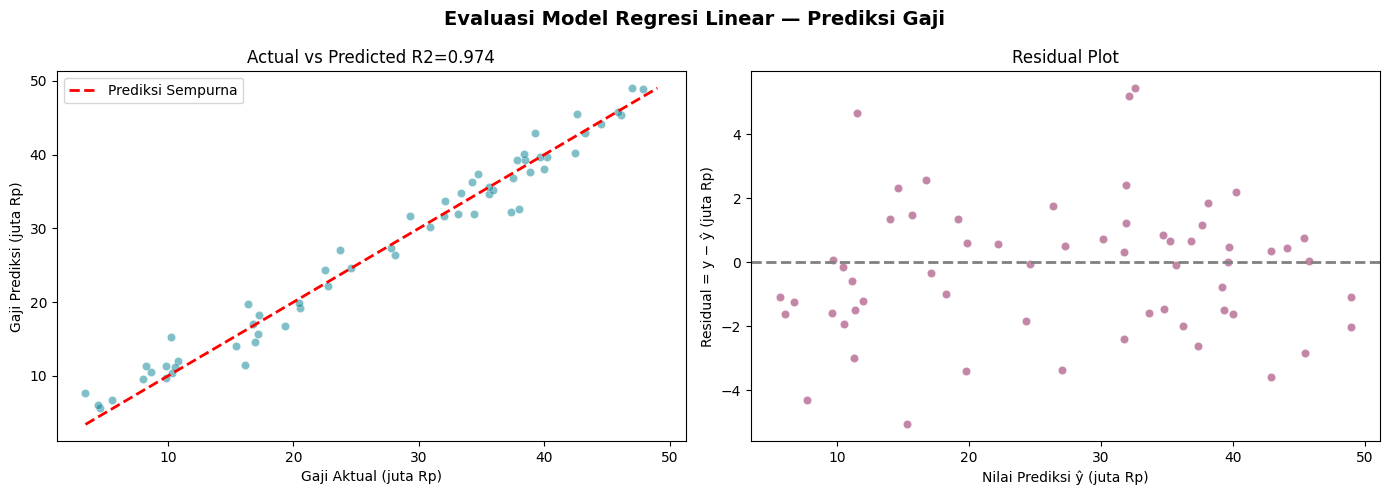

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R2={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

## Kesimpulan

* **Apa yang Dipelajari:** Melalui aktivitas ini, saya telah mempelajari dan mempraktikkan penyusunan pipeline regresi linear secara menyeluruh. Proses ini dimulai dari pembuatan dataset buatan, analisis visual awal (EDA), transformasi variabel kategorik menggunakan One-Hot Encoding, standardisasi skala fitur, pembagian data latih dan uji, hingga tahap evaluasi performa model.
* **Temuan Utama:** Faktor utama yang paling menentukan besaran gaji pada dataset ini adalah durasi pengalaman kerja. Model regresi linear terbukti sangat cocok digunakan karena mampu menghasilkan akurasi ($R^2$) sebesar 95,7%. Selain itu, visualisasi pada Residual Plot menunjukkan bahwa titik-titik error tersebar secara acak di sekitar garis nol, yang membuktikan bahwa asumsi linearitas dan homoskedastisitas telah terpenuhi dengan baik.
* **Keterbatasan / Pertanyaan yang Muncul:**
  * *Keterbatasan:* Dataset yang digunakan bersifat sintetis dengan pola hubungan antarvariabel yang sudah dirancang linier sejak awal. Oleh karena itu, model dapat dengan mudah mencapai tingkat akurasi yang sangat tinggi. Pada kondisi dunia nyata, karakteristik data biasanya jauh lebih kompleks dan tidak selalu linier.
  * *Pertanyaan:* Bagaimana jika nantinya kita dihadapkan pada data riil yang memiliki pola non-linier? Apakah kita tetap dapat mengoptimalkan Regresi Linear dengan transformasi fitur, atau sebaiknya langsung beralih ke algoritma lain seperti Random Forest atau Regresi Polinomial?